### Homework: going neural (6 pts)

We've checked out statistical approaches to language models in the last notebook. Now let's go find out what deep learning has to offer.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/expanding_mind_lm_kn_3.png' width=300px>

We're gonna use the same dataset as before, except this time we build a language model that's character-level, not word level. Before you go:
* If you haven't done seminar already, use `seminar.ipynb` to download the data.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Working on character level means that we don't need to deal with large vocabulary or missing words. Heck, we can even keep uppercase words in text! The downside, however, is that all our sequences just got a lot longer.

However, we still need special tokens:
* Begin Of Sequence  (__BOS__) - this token is at the start of each sequence. We use it so that we always have non-empty input to our neural network. $P(x_t) = P(x_1 | BOS)$
* End Of Sequence (__EOS__) - you guess it... this token is at the end of each sequence. The catch is that it should __not__ occur anywhere else except at the very end. If our model produces this token, the sequence is over.


In [8]:
BOS, EOS = ' ', '\n'

data = pd.read_json("/content/arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

# if you missed the seminar, download data here - https://yadi.sk/d/_nGyU2IajjR9-w

Our next step is __building char-level vocabulary__. Put simply, you need to assemble a list of all unique tokens in the dataset.

In [9]:
# get all unique characters from lines (including capital letters and symbols)
tokens = set()

for line in lines:
    tokens.update(line)

tokens.update([BOS, EOS]) #чат гпт сказал что до bos в конце это норм, так как нам нужно сначала просто все токены собрать а потом в начало запишем

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


We can now assign each character with its index in tokens list. This way we can encode a string into a torch-friendly integer vector.

In [10]:
# dictionary of character -> its identifier (index in tokens list)
token_to_id = {token: i for i, token in enumerate(tokens)}
#делаем пары вида индекс токен

In [11]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


Our final step is to assemble several strings in a integer matrix with shape `[batch_size, text_length]`.

The only problem is that each sequence has a different length. We can work around that by padding short sequences with extra `"EOS"` tokens or cropping long sequences. Here's how it works:

In [12]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [13]:
#Example: cast 4 random names to a single matrix, pad with zeros where needed.
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))



[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


### Neural Language Model (2 points including training)

Just like for N-gram LMs, we want to estimate probability of text as a joint probability of tokens (symbols this time).

$$P(X) = \prod_t P(x_t \mid x_0, \dots, x_{t-1}).$$

Instead of counting all possible statistics, we want to train a neural network with parameters $\theta$ that estimates the conditional probabilities:

$$ P(x_t \mid x_0, \dots, x_{t-1}) \approx p(x_t \mid x_0, \dots, x_{t-1}, \theta) $$


But before we optimize, we need to define our neural network. Let's start with a fixed-window (aka convolutional) architecture:

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/fixed_window_lm.jpg' width=400px>


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [27]:
class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=64):
        super().__init__()
        """
        A fixed window model that looks on at least 5 previous symbols.

        Note: fixed window LM is effectively performing a convolution over a sequence of words.
        This convolution only looks on current and previous words.
        Such convolution can be represented as a sequence of 2 operations:
        - pad input vectors by {strides * (filter_size - 1)} zero vectors on the "left", do not pad right
        - perform regular convolution with {filter_size} and {strides}

        - If you're absolutely lost, here's a hint: use nn.ZeroPad2d((NUM_LEADING_ZEROS, 0, 0, 0))
          followed by a nn.Conv1d(..., padding=0). And yes, its okay that padding is technically "2d".


        Идея:
        1. превращаем индексы токенов в эмбеддинги;
        2. делаем свертку по последовательности;
        3. для каждой позиции получаем logits по всем токенам словаря.
        """
        #super().__init__() # initialize base class to track sub-layers, trainable variables, etc.

        # YOUR CODE - create layers/variables and any metadata you want, e.g. self.emb = L.Embedding(...)

        #<...>

        #END OF YOUR CODE

        #super().__init__()

        # сохраним размер словаря, чтобы было удобно
        self.n_tokens = n_tokens

        # embedding: каждому токену сопоставляем вектор длины emb_size
        # вход:  [batch, seq_len]
        # выход: [batch, seq_len, emb_size]
        self.emb = nn.Embedding(n_tokens, emb_size)

        # хотим, чтобы модель смотрела как минимум на 5 предыдущих символов
        # значит можно взять kernel_size = 6:
        # текущая позиция + 5 символов слева
        self.kernel_size = 6

        # слева нужно добавить kernel_size - 1 нулевых векторов,
        # чтобы на первых позициях тоже можно было сделать свертку
        #
        # ZeroPad2d((left, right, top, bottom))
        # мы будем подавать тензор формы [batch, channels, length],
        # поэтому padding слева по "length" делается так:
        self.pad = nn.ZeroPad2d((self.kernel_size - 1, 0, 0, 0))

        # одномерная свертка по последовательности
        # вход:  [batch, emb_size, seq_len]
        # выход: [batch, hid_size, seq_len]
        self.conv = nn.Conv1d(
            in_channels=emb_size,
            out_channels=hid_size,
            kernel_size=self.kernel_size,
            padding=0
        )

        # нелинейность после свертки
        self.act = nn.ReLU()

        # финальный линейный слой:
        # из скрытого состояния длины hid_size получаем logits по всем токенам
        # вход:  [batch, seq_len, hid_size]
        # выход: [batch, seq_len, n_tokens]
        self.out = nn.Linear(hid_size, n_tokens)


    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})

        :note: that convolutions operate with tensors of shape [batch, channels, length], while linear layers
         and *embeddings* use [batch, length, channels] tensors. Use tensor.permute(...) to adjust shapes.

         Метод __call__ получает батч индексов токенов и возвращает logits для каждого токена в каждой позиции.
         Embedding и Linear используют формат [batch, length, channels]
         а Conv1d — [batch, channels, length], поэтому перед сверткой и
         после нее нужно переставлять оси через permute вроде как

        """
        # 1) переводим индексы токенов в эмбеддинги
        # [batch, seq_len] -> [batch, seq_len, emb_size]
        x = self.emb(input_ix)

        # 2) для Conv1d нужно поменять порядок осей:
        # [batch, seq_len, emb_size] -> [batch, emb_size, seq_len]
        x = x.permute(0, 2, 1)

        # 3) добавляем нулевые векторы слева
        # длина последовательности увеличится на kernel_size - 1
        x = self.pad(x)

        # 4) делаем свертку
        # [batch, emb_size, padded_len] -> [batch, hid_size, seq_len]
        x = self.conv(x)

        # 5) применяем нелинейность
        x = self.act(x)

        # 6) возвращаем оси обратно для линейного слоя:
        # [batch, hid_size, seq_len] -> [batch, seq_len, hid_size]
        x = x.permute(0, 2, 1)

        # 7) получаем logits по всем токенам словаря
        # [batch, seq_len, hid_size] -> [batch, seq_len, n_tokens]
        logits = self.out(x)

        return logits
        # YOUR CODE - apply layers, see docstring above
        #return <...> # output tensor should be of shape [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        #prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64) cuda
        prefix_ix = torch.as_tensor(
        to_matrix([prefix]),
        dtype=torch.int64,
        device=next(self.parameters()).device
        )
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))


In [15]:
dummy_model = FixedWindowLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'conv.weight', 'conv.bias', 'out.weight', 'out.bias')


In [16]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [17]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."


#Модель не должна зависеть от будущих токенов.
#Поэтому в Conv1d я делаю только левый padding и не использую симметричный padding:
#тогда предсказание в позиции t зависит только от текущего и предыдущих токенов.

We can now tune our network's parameters to minimize categorical crossentropy over training dataset $D$:

$$ L = {\frac1{|D|}} \sum_{X \in D} \sum_{x_i \in X} - \log p(x_t \mid x_1, \dots, x_{t-1}, \theta) $$

As usual with with neural nets, this optimization is performed via stochastic gradient descent with backprop.  One can also note that minimizing crossentropy is equivalent to minimizing model __perplexity__, KL-divergence or maximizng log-likelihood.

In [18]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [21]:
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    #input_ix = torch.as_tensor(input_ix, dtype=torch.int64) куда
    input_ix = torch.as_tensor(
        input_ix,
        dtype=torch.int64,
        device=next(model.parameters()).device
    )

    logits = model(input_ix[:, :-1]) # [batch, length-1, n_tokens]
    reference_answers = input_ix[:, 1:]  # [batch, length-1]

    # Your task: implement loss function as per formula above
    # your loss should only be computed on actual tokens, excluding padding
    # predicting actual tokens and first EOS do count. Subsequent EOS-es don't
    # you may or may not want to use the compute_mask function from above.

    # маска: считаем все токены до первого EOS включительно,
    # а все последующие EOS-паддинги игнорируем
    mask = compute_mask(input_ix)[:, 1:]      # [batch, length-1]

    # crossentropy по каждому токену отдельно
    loss_per_token = F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        reference_answers.reshape(-1),
        reduction='none'
    ).reshape(reference_answers.shape)

    # усредняем только по нужным позициям
    loss = (loss_per_token * mask).sum() / mask.sum()

    return loss


In [22]:
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

### Evaluation

You will need two functions: one to compute test loss and another to generate samples. For your convenience, we implemented them both in your stead.

In [25]:
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.
    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = to_matrix(dev_lines[i: i + batch_size])
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    prefix_ix = torch.as_tensor(
    to_matrix([prefix]),
    dtype=torch.int64,
    device=next(model.parameters()).device
    )
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

### Training loop

Finally, let's train our model on minibatches of data

In [28]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
#train_history, dev_history = [], []
#model = FixedWindowLanguageModel()
#opt = torch.optim.Adam(model.parameters())
#подключаем куду
train_history, dev_history = [], []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = FixedWindowLanguageModel().to(device)
opt = torch.optim.Adam(model.parameters())

# hint: if you ever wanted to switch to cuda, do it now.

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

cuda
Sample before training: BridgingpśóghC0êaxq~ΣH[|${!ÉHPΣ7ozuàβ*ïő'S2α~χΣruõvl,WMaεd1ŁJ*æàRê&εfXŁωuetHwÉpà(w@Pσőï8α"nU3}3őêpx&'


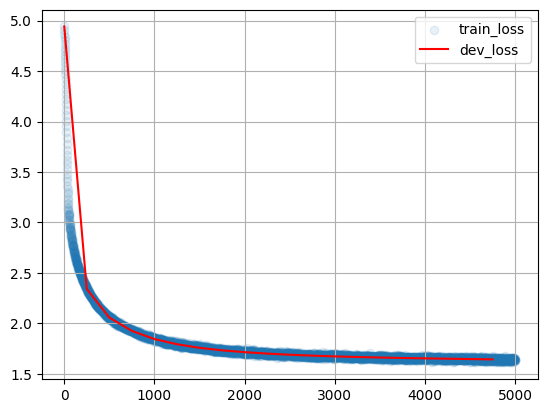

Generated examples (tau=0.5):
 For have and structures for and algorithor corting has consider to bethese the becation of the strat
 A Distric stanaits to context is the consis and with propose resulter to problem to and recognition 
 Socies and the resters partical semportant poages and is in on the problem from a computation mintar
Scoring dev...


100%|██████████| 5000/5000 [02:53<00:00, 28.75it/s]

#4999 Dev loss: 1.640


In [29]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))


    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])


In [30]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.6395249311633227
 has sempresent a not of the in the strative and patters and emporting rearning a sime arred and prob
 Adversain distance of extence and subject recognitation based on the such madely estimates in the co
 Many a propose a not using method training and Model simple a to the propose a neural networks in lo
 Complexitions and to incout of machine unter and optimated acheration and the been and intain sime a
 Information of field variable incrandical computation of the neural networks of the extraction and a
 On the model the comption ; We problem solve the semporal networks for incracting the decomentic com
 Of domuntaric method assundation of annomatical retection and the dith is a problem of motic languag
 Sanding of a new for semorithm of General networks for the main task is reated in the subpose and st
 Despers images. In a learning interions a repilly exp or a setton the sechnal interm of the explores
 Computation sparance in the fies and to depend

### RNN Language Models (3 points including training)

Fixed-size architectures are reasonably good when capturing short-term dependencies, but their design prevents them from capturing any signal outside their window. We can mitigate this problem by using a __recurrent neural network__:

$$ h_0 = \vec 0 ; \quad h_{t+1} = RNN(x_t, h_t) $$

$$ p(x_t \mid x_0, \dots, x_{t-1}, \theta) = dense_{softmax}(h_{t-1}) $$

Such model processes one token at a time, left to right, and maintains a hidden state vector between them. Theoretically, it can learn arbitrarily long temporal dependencies given large enough hidden size.

<img src='https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/rnn_lm.jpg' width=480px>

Fixed-window модель видит только короткий контекст, а RNN обрабатывает последовательность по одному токену слева направо и хранит скрытое состояние. Благодаря этому она может учитывать более длинные зависимости в тексте.

In [31]:
class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256):
        """
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits

        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__()

        # размер словаря сохраним для удобства
        self.n_tokens = n_tokens

        # embedding: превращает индекс токена в вектор
        # [batch, seq_len] -> [batch, seq_len, emb_size]
        self.emb = nn.Embedding(n_tokens, emb_size)

        # рекуррентный слой
        # batch_first=True, значит вход и выход имеют вид
        # [batch, seq_len, features]
        self.rnn = nn.GRU(
            input_size=emb_size,
            hidden_size=hid_size,
            batch_first=True
        )

        # линейный слой переводит скрытое состояние в logits по словарю
        # [batch, seq_len, hid_size] -> [batch, seq_len, n_tokens]
        self.out = nn.Linear(hid_size, n_tokens)

        #END OF YOUR CODE

    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """
        # YOUR CODE - apply layers, see docstring above
        # 1) индексы токенов -> эмбеддинги
        x = self.emb(input_ix)   # [batch, seq_len, emb_size]

        # 2) прогоняем через GRU
        # nn.GRU возвращает:
        # - output для каждой позиции: [batch, seq_len, hid_size]
        # - последнее hidden state, оно здесь не нужно
        rnn_out, _ = self.rnn(x)

        # 3) из скрытых состояний получаем logits по всем токенам
        logits = self.out(rnn_out)   # [batch, seq_len, n_tokens]

        return logits
        #return <...> # output tensor should be of shape [batch_size, sequence_length, n_tokens]

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(
            to_matrix([prefix]),
            dtype=torch.int64,
            device=next(self.parameters()).device
        )
        #prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))


In [32]:
model = RNNLanguageModel()

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'rnn.weight_ih_l0', 'rnn.weight_hh_l0', 'rnn.bias_ih_l0', 'rnn.bias_hh_l0', 'out.weight', 'out.bias')


In [33]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

### RNN training

Our RNN language model should optimize the same loss function as fixed-window model. But there's a catch. Since RNN recurrently multiplies gradients through many time-steps, gradient values may explode, [ruining](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/nan.jpg) your model.
The common solution to that problem is to clip gradients either [individually](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_value) or [globally](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/clip_by_global_norm).

Your task here is to implement the training code that minimizes the loss function. If you encounter large loss fluctuations during training, please add [gradient clipping](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html) using urls above. But its **not necessary** to use gradient clipping if you don't need it.

_Note: gradient clipping is not exclusive to RNNs. Convolutional networks with enough depth often suffer from the same issue._

RNN обучается с той же функцией потерь, что и fixed-window модель. При обучении градиенты могут взрываться, поэтому после loss.backward() можно применять gradient clipping, например clip_grad_norm_(model.parameters(), 1.0), и только потом делать opt.step().

In [34]:
batch_size = 64         # <-- please tune batch size to fit your CPU/GPU configuration
score_dev_every = 250
train_history, dev_history = [], []

model = RNNLanguageModel(n_tokens).to(device)
opt = torch.optim.Adam(model.parameters())

# score untrained model
dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridging>|LöΣOL4=æj.y3vμ+Xè^t"fAv?εaãè5ΩλõjztΩ,VJCJàkXZ;ŁŁ|&uZ3



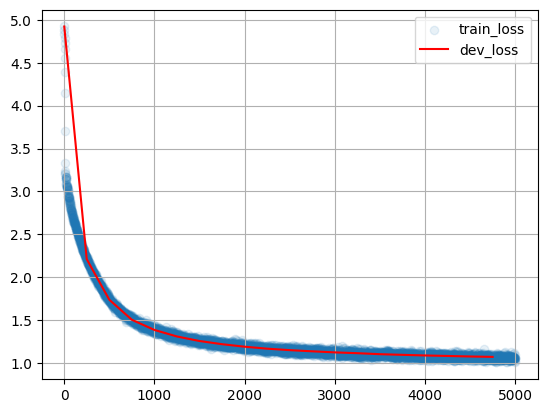

Generated examples (tau=0.5):
 Comparison of the Constraint Probability ; In this paper, we investigate the being descent as a set 
 Problem of Data with Large-Scale Convolutional Neural Networks ; In this paper, we propose an expert
 Probabilistic Generation of Multiplicative Neural Networks ; This paper describes the problem of eac
Scoring dev...


100%|██████████| 5000/5000 [04:58<00:00, 16.77it/s]

#4999 Dev loss: 1.067


In [35]:
from IPython.display import clear_output
from random import sample
from tqdm import trange
import torch.nn.utils as nn_utils

for i in trange(len(train_history), 5000):
    # случайно берем batch строк из train
    batch = to_matrix(sample(train_lines, batch_size))

    # обнуляем старые градиенты
    opt.zero_grad()

    # считаем loss на текущем batch
    loss_i = compute_loss(model, batch)

    # считаем градиенты
    loss_i.backward()

    # обрезаем слишком большие градиенты, чтобы обучение не "взрывалось"
    nn_utils.clip_grad_norm_(model.parameters(), 1.0)

    # делаем шаг оптимизации
    opt.step()

    # сохраняем значение loss в историю
    train_history.append((i, float(loss_i)))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend()
        plt.grid()
        plt.show()

        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [37]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "Egor go to sleep"
print("Final dev loss:", dev_history[-1][-1])
for i in range(10):
    print(generate(model, temperature=0.5))

Final dev loss: 1.0674584296389324
 A Deep Learning for Multi-Armed Interaction and Monte Convolutional Neural Network ; In this paper, 
 Learning to Machine Learning ; The automatic methods for the algorithm for the training data is solv
 Segmented Markov Convolutional Neural Networks ; The deep learning method is a crowd evolution of st
 Compression of Close Bayes with Correlation of Conversation ; This paper presents the problem of an 
 Recurrent Neural Networks with an Interpolation of Bolless ; We propose a novel complex theoretic me
 Sequential Neural Networks for Linear Shallow Segmentation ; The field of interest is a recent work 
 Statistical Distributed Neural Networks for Recurrent Neural Networks ; In this paper, we propose a 
 How for Different Domain Computational Deep Learning ; We present a novel approach to recognize an a
 The Inference Image Decomposition with Deep Convolution Context ; We propose a novel method to detec
 The Deep Learning for Search Concepts ; In thi

### Alternative sampling strategies (1 point)

So far we've sampled tokens from the model in proportion with their probability.
However, this approach can sometimes generate nonsense words due to the fact that softmax probabilities of these words are never exactly zero. This issue can be somewhat mitigated with sampling temperature, but low temperature harms sampling diversity. Can we remove the nonsense words without sacrificing diversity? __Yes, we can!__ But it takes a different sampling strategy.

__Top-k sampling:__ on each step, sample the next token from __k most likely__ candidates from the language model.

Suppose $k=3$ and the token probabilities are $p=[0.1, 0.35, 0.05, 0.2, 0.3]$. You first need to select $k$ most likely words and set the probability of the rest to zero: $\hat p=[0.0, 0.35, 0.0, 0.2, 0.3]$ and re-normalize:
$p^*\approx[0.0, 0.412, 0.0, 0.235, 0.353]$.

__Nucleus sampling:__ similar to top-k sampling, but this time we select $k$ dynamically. In nucleus sampling, we sample from top-__N%__ fraction of the probability mass.

Using the same  $p=[0.1, 0.35, 0.05, 0.2, 0.3]$ and nucleus N=0.9, the nucleus words consist of:
1. most likely token $w_2$, because $p(w_2) < N$
2. second most likely token $w_5$, $p(w_2) + p(w_5) = 0.65 < N$
3. third most likely token $w_4$ because $p(w_2) + p(w_5) + p(w_4) = 0.85 < N$

And thats it, because the next most likely word would overflow: $p(w_2) + p(w_5) + p(w_4) + p(w_1) = 0.95 > N$.

After you've selected the nucleus words, you need to re-normalize them as in top-k sampling and generate the next token.

__Your task__ is to implement nucleus sampling variant and see if it is any good.

Мы берем все вероятности следующего токена, которые дала модель.

Потом сортируем токены от самых вероятных к менее вероятным.

Дальше берем только верхнюю часть списка — столько токенов, чтобы их суммарная вероятность дошла, например, до 0.9.

То есть:

самые вероятные оставляем,
слишком маловероятные отбрасываем.

После этого заново нормируем вероятности только у оставшихся токенов и случайно выбираем следующий токен уже из них.

Зачем это нужно:

модель меньше выбирает совсем бредовые символы или слова;
при этом генерация остается разнообразной.


In [44]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    r"""
    Generate a sequence with nucleus sampling
    :param prefix: a string containing space-separated previous tokens
    :param nucleus: N from the formulae above, N \in [0, 1]
    :param max_len: generate sequences with at most this many tokens, including prefix

    :note: make sure that nucleus always contains at least one word, even if p(w*) > nucleus

    """
    while True:
        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())
        probs = np.array(probs)

        # сортируем токены по вероятности по убыванию
        order = np.argsort(probs)[::-1]
        sorted_tokens = [tokens[i] for i in order]
        sorted_probs = probs[order]

        # накапливаем сумму вероятностей
        cumsum = np.cumsum(sorted_probs)

        # берем минимальное число токенов, чтобы покрыть nucleus
        nucleus_size = np.searchsorted(cumsum, nucleus) + 1

        # оставляем только nucleus-токены
        nucleus_tokens = sorted_tokens[:nucleus_size]
        nucleus_probs = sorted_probs[:nucleus_size]

        # нормируем вероятности заново
        nucleus_probs = nucleus_probs / nucleus_probs.sum()

        # выбираем следующий токен
        next_token = np.random.choice(nucleus_tokens, p=nucleus_probs)

        prefix += next_token
        if next_token == EOS or len(prefix) > max_len: break
    return prefix

Мы берем вероятности следующего токена, сортируем их, оставляем только самые вероятные токены, которые вместе дают нужную суммарную вероятность nucleus, заново нормируем их и случайно выбираем следующий токен только из них.

In [45]:
for i in range(10):
    print(generate_nucleus(model, nucleus=0.9))

 Online Autoencopyred Networks for Multi-point Multiclass Doints ; We present a model for unsupervise
 Transfer Speech Recurrent Doen Programs to Inference Transfer Interpolation ; Many color causes appl
 On the development of AIM with Smal-wides by Neuro defo and   values of computer vision ; Computatio
 Such Learning and Multi-Exister Extraction to Recognition of Measure Tand symptation ; In this work 
 Learning to Convolutional Networks ; Multiple in making space challenges is important preferences fr
 Multi-Expected Machine Multi-Time Bayes It and Plane Ranking ; This paper presents a benchmark for f
 Commonic Neural Networks for Expected Architecture Instance Model ; Data is encoded by challenging t
 Main Measure Principal to Marking Based On a Leading Arraigh Sentime   Dataset ; We evaluate systems
 Designing for Generative Machine Multimodal   Fusion for Neural Networks with Applications ; While i
 Active Set Theory of Severility to Data Recommendation ; A human-like approach fo